# 1. Libraries

In [1]:
import sys
sys.path.append("../src")

In [2]:
# Project imports
from data_utils import create_full_dataset_for_participant
from engineered_features import create_features

# Data science libraries
import pandas as pd
import numpy as np

# Machine learning libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Grid search for optimal window size and step size

In [3]:
participant_id = 6

In [4]:
window_sizes = [128, 256, 512, 1024, 2048]
step_sizes = [64, 128, 256, 512, 1024]

In [5]:
def grid_search_for_optimal_window_size(participant_id, window_sizes, step_sizes):
    for window_size in window_sizes:
        for step_size in step_sizes:
            X, y, feature_names = create_full_dataset_for_participant(participant_id, window_size, step_size)
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, stratify=y, random_state=42)
            model = RandomForestClassifier(n_estimators=100, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            model_report = classification_report(y_test, y_pred, output_dict=True)
            accuracy = model_report['accuracy']
            print(f"Window Size: {window_size}, Step Size: {step_size}, Accuracy: {accuracy}")
            if accuracy > 0.95:
                print(f"Optimal window size found: {window_size} with step size {step_size}")
                print("Classification Report:\n", classification_report(y_test, y_pred))
                print("Confusion Matrix:")
                sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
                plt.xlabel("Predicted")
                plt.ylabel("True")
                plt.show()
                return X, y, window_size, step_size, model, feature_names

Window Size: 128, Step Size: 64, Accuracy: 0.92578125
Window Size: 128, Step Size: 128, Accuracy: 0.8984375
Window Size: 128, Step Size: 256, Accuracy: 0.8125
Window Size: 128, Step Size: 512, Accuracy: 0.75
Window Size: 128, Step Size: 1024, Accuracy: 0.875
Window Size: 256, Step Size: 64, Accuracy: 0.9565217391304348
Optimal window size found: 256 with step size 64
Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.98      0.96       127
         1.0       0.98      0.93      0.96       126

    accuracy                           0.96       253
   macro avg       0.96      0.96      0.96       253
weighted avg       0.96      0.96      0.96       253

Confusion Matrix:


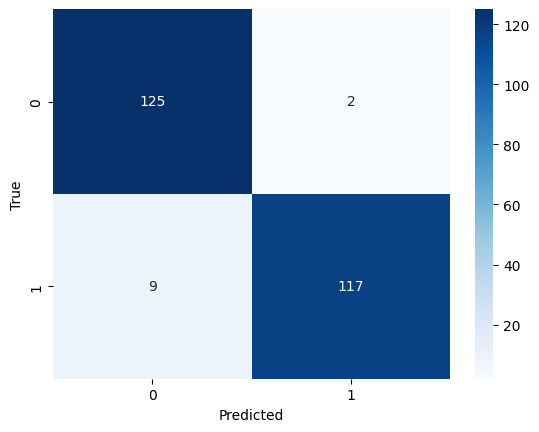

In [6]:
X, y, window_size, step_size, model, feature_names = grid_search_for_optimal_window_size(participant_id, window_sizes, step_sizes)

# 2. Feature selection via MDI

MDI (Mead Decrease in Impurity) scores for the features

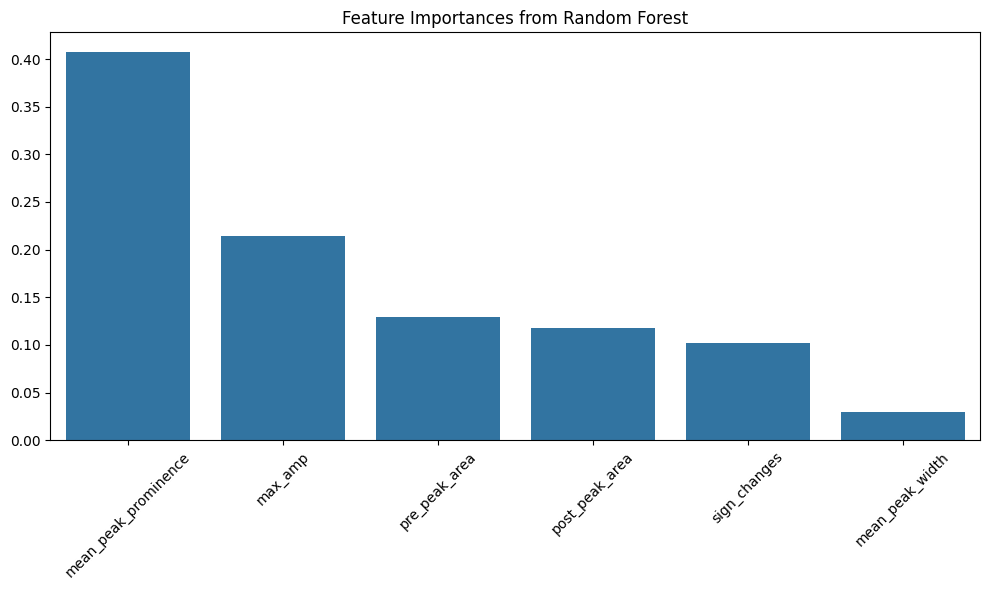

In [7]:
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=[feature_names[i] for i in sorted_idx], y=importances[sorted_idx])
plt.xticks(rotation=45)
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()

Select the top 3 features

In [8]:
selected_features = [feature_names[i] for i in sorted_idx][:3]
df = pd.DataFrame(X, columns=feature_names)
df = df[selected_features].round(2)
df["label"] = y

Optionally, save the features.

In [ ]:
# df.to_csv("../output/features_for_sirus.csv", index=False)

# 4. Rule-based classification using SIRUS

Now, we go to R to run the rule-extractor `SIRUS`, and get back the best fit rules.

In [17]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# Push pandas DataFrame to R using context manager
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['features_for_sirus'] = ro.conversion.py2rpy(df)

# R code block
ro.r('''
require(sirus)

data <- features_for_sirus[, -ncol(features_for_sirus)]
data <- as.data.frame(data)
y <- features_for_sirus$label

sirus.m <- sirus.fit(data, y)
rules <- capture.output(sirus.print(sirus.m))
y_pred <- ifelse(sirus.predict(sirus.m, data) < 0.5, 0, 1)
''')

# Pull back predictions and rules
with localconverter(ro.default_converter + pandas2ri.converter):
    y_pred = np.array(ro.r('y_pred'), dtype=int)
    rules = list(ro.r('rules'))


[1] "Number of trees:  1000  - Stability  89.25  %."
[1] "Number of trees:  2000  - Stability  89.65  %."
[1] "Number of trees:  3000  - Stability  90.75  %."
[1] "Number of trees:  4000  - Stability  91.25  %."
[1] "Number of trees:  5000  - Stability  91.34  %."
[1] "Number of trees:  6000  - Stability  92.32  %."
[1] "Number of trees:  7000  - Stability  92.47  %."
[1] "Number of trees:  8000  - Stability  92.66  %."
[1] "Number of trees:  9000  - Stability  93.22  %."
[1] "Number of trees:  10000  - Stability  92.82  %."
[1] "Number of trees:  11000  - Stability  93.35  %."
[1] "Number of trees:  12000  - Stability  93.16  %."
[1] "Number of trees:  13000  - Stability  93.5  %."
[1] "Number of trees:  14000  - Stability  93.32  %."
[1] "Number of trees:  15000  - Stability  93.49  %."
[1] "Number of trees:  16000  - Stability  93.63  %."
[1] "Number of trees:  17000  - Stability  94.05  %."
[1] "Number of trees:  18000  - Stability  94.59  %."
[1] "Number of trees:  19000  - Stabil

In [18]:
rules

[' [1] "Proportion of class 1 = 0.5 - Sample size n = 316"                                                 ',
 ' [2] "if mean_peak_prominence < 45.1 then 0.057 (n=158) else 0.943 (n=158)"                              ',
 ' [3] "if label < 1 then 0 (n=158) else 1 (n=158)"                                                        ',
 ' [4] "if max_amp < 69.7 then 0.0886 (n=158) else 0.911 (n=158)"                                          ',
 ' [5] "if pre_peak_area < 1190 then 0.102 (n=157) else 0.893 (n=159)"                                     ',
 ' [6] "if max_amp < 69.7 & pre_peak_area < 1190 then 0.0604 (n=149) else 0.892 (n=167)"                   ',
 ' [7] "if mean_peak_prominence >= 45.1 & mean_peak_prominence < 62.8 then 0.71 (n=31) else 0.477 (n=285)" ',
 ' [8] "if mean_peak_prominence >= 38.1 & mean_peak_prominence < 45.1 then 0.281 (n=32) else 0.525 (n=284)"',
 ' [9] "if mean_peak_prominence < 45.1 & pre_peak_area < 1190 then 0.0417 (n=144) else 0.884 (n=172)"      ',
 '[10] "if

Some of the most prominent rules for each participant. However, note that this manual rule pruning might not be stable. Whereas SIRUS is proven to be stable.

In [12]:
# def rule_for_participant(window_features, participant_id):
#     match participant_id:
#         case 0:
#             return window_features['mean_peak_prominence'] >= 59.5 # 90% accuracy -> 93% accuracy
#         case 3:
#             return window_features['max_amp'] >= 31.9 # 94% accuracy -> 95% accuracy
#         case 5:
#             return window_features['sign_changes'] > 178 # 100% accuracy -> 100% accuracy
#         case 6:
#             return window_features['mean_peak_prominence'] >= 45.1 # 91% accuracy -> 94% accuracy
#         case 7:
#             return window_features['mean_peak_prominence'] < 94.8 # 97% accuracy -> 97% accuracy
#         case 8:
#             return window_features['max_amp'] >= 75.2 # 98% accuracy -> 96% accuracy
#         case 9:
#             return window_features['max_amp'] < 71.9 # 97% accuracy -> 98% accuracy
#         case 10:
#             return window_features['pre_peak_area'] < 2550 # 91% accuracy -> 92% accuracy


# rule = lambda window_features: rule_for_participant(window_features, participant_id)

# df['rule_label'] = df.apply(rule, axis=1).astype(int)    

We take the averaged prediction of the rules, given by SIRUS.

In [19]:
df["rule_label"] = y_pred

In [20]:
df

,mean_peak_prominence,max_amp,pre_peak_area,label,rule_label
0,35.29,39.47,993.77,0.0,0
1,40.11,43.78,1096.75,0.0,0
2,38.11,43.78,1096.75,0.0,0
3,43.11,43.78,1096.75,0.0,0
4,35.07,43.48,1096.75,0.0,0
...,...,...,...,...,...
311,100.71,150.00,2551.24,1.0,1
312,83.60,152.35,2551.24,1.0,1
313,117.04,175.17,2551.24,1.0,1
314,178.95,263.06,4625.69,1.0,1


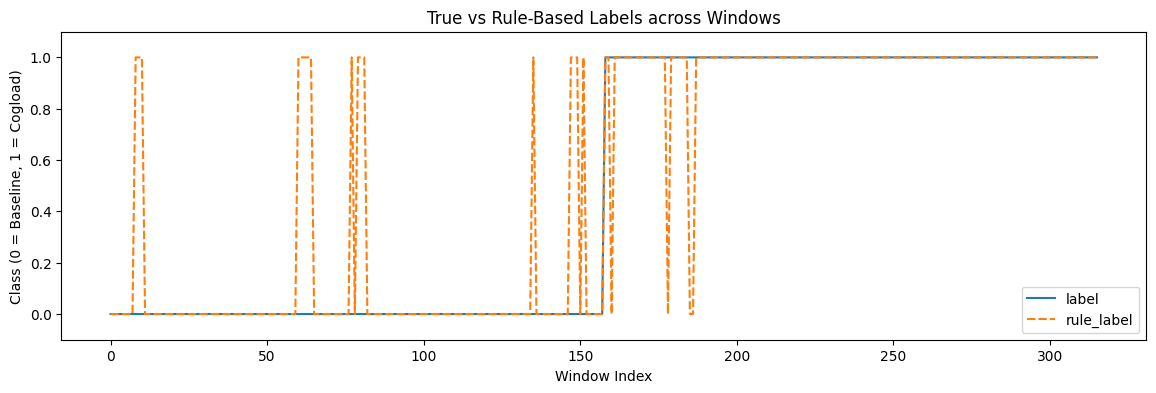

In [21]:
plt.figure(figsize=(14, 4))
sns.lineplot(data=df[['label', 'rule_label']])
plt.xlabel("Window Index")
plt.ylabel("Class (0 = Baseline, 1 = Cogload)")
plt.title("True vs Rule-Based Labels across Windows")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

In [22]:
accuracy = (df["label"] == df["rule_label"]).mean()
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.93
